# MS22: Artifical Intelligence & Machine learning

## Multi-Output Time-series Forecasting

Name : Saurabh

Roll no : 25MAM035

This notebook predicts the next 5 days of NTPC stock values using the previous 5 days of data.

Dataset used: NTPC.csv from NIFTY-50 Stock Market Data.

Model used: LSTM in PyTorch. A GRU model is also written, so it can be used by changing one line.

## Import Libraries

The main model is made using PyTorch. Pandas and NumPy are used for data handling.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Basic Settings

The input window is 5 days and the output horizon is also 5 days, as required in the assignment.

In [5]:
DATA_PATH = Path(r"C:\Users\Lenovo\OneDrive - Jamia Millia Islamia (A Central University)\Desktop\NTPC\NTPC.csv")

WINDOW_SIZE = 5
PRED_HORIZON = 5

BATCH_SIZE = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 1
LR = 0.001
EPOCHS = 30

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

Using: cpu


## Load Dataset

The selected file is NTPC.csv.

In [6]:
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2004-11-05,NTPC,EQ,62.00,88.00,88.00,70.00,75.55,75.55,73.12,232535736,1.700363e+15,NaN,115350904,0.4961
1,2004-11-08,NTPC,EQ,75.55,76.80,78.60,75.00,75.15,75.20,76.88,68865277,5.294024e+14,NaN,25571231,0.3713
2,2004-11-09,NTPC,EQ,75.20,75.10,76.10,74.55,75.25,75.30,75.28,37460886,2.820236e+14,NaN,13585363,0.3627
3,2004-11-10,NTPC,EQ,75.30,75.50,75.95,75.00,75.05,75.05,75.32,17413433,1.311585e+14,NaN,7039001,0.4042
4,2004-11-11,NTPC,EQ,75.05,75.35,75.40,74.30,74.60,74.45,74.74,15961426,1.193037e+14,NaN,7286922,0.4565


## Data Cleaning

Here duplicates are removed, date format is corrected, rows are sorted by date, and missing values are filled.

In [7]:
print("Shape before cleaning:", df.shape)
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.drop_duplicates()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

Shape before cleaning: (4088, 15)
Missing values before cleaning:
Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                1632
Deliverable Volume       0
%Deliverble              0
dtype: int64


## Select 11 Numerical Features

The assignment asks to use 11 stock features for multi-output forecasting.

In [8]:
features = [
    "Prev Close",
    "Open",
    "High",
    "Low",
    "Last",
    "Close",
    "VWAP",
    "Volume",
    "Turnover",
    "Trades",
    "Deliverable Volume",
]

for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[features] = df[features].interpolate(method="linear", limit_direction="both")
df[features] = df[features].ffill().bfill()

df = df.dropna(subset=["Date"] + features).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:")
print(df[features].isnull().sum())

Shape after cleaning: (4088, 15)
Missing values after cleaning:
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64


## Train-Test Split and Normalization

For time-series data, the first 80 percent of rows are used for training and the remaining rows are used for testing.

The scaler is fitted only on training data, then applied to both train and test data.

In [9]:
def create_sequences(data, window, horizon):
    X = []
    y = []

    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i + window])
        y.append(data[i + window:i + window + horizon])

    return np.array(X), np.array(y)

In [10]:
train_size = int(0.8 * len(df))

train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size - WINDOW_SIZE:].copy()

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features])
test_scaled = scaler.transform(test_df[features])

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, PRED_HORIZON)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE, PRED_HORIZON)

test_dates = test_df["Date"].iloc[WINDOW_SIZE:WINDOW_SIZE + len(X_test)].reset_index(drop=True)

y_train = y_train.reshape(y_train.shape[0], -1)
y_test = y_test.reshape(y_test.shape[0], -1)

print("Train input shape:", X_train.shape)
print("Train output shape:", y_train.shape)
print("Test input shape:", X_test.shape)
print("Test output shape:", y_test.shape)

Train input shape: (3261, 5, 11)
Train output shape: (3261, 55)
Test input shape: (814, 5, 11)
Test output shape: (814, 55)


## PyTorch Dataset and DataLoader

The NumPy arrays are converted into PyTorch tensors for model training.

In [11]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_loader = DataLoader(
    StockDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    StockDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

## LSTM and GRU Models

Both models take 5 days of 11 features as input and predict 5 future days of all 11 features.

In [12]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=len(features),
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True
        )

        self.fc = nn.Linear(HIDDEN_SIZE, PRED_HORIZON * len(features))

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.gru = nn.GRU(
            input_size=len(features),
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True
        )

        self.fc = nn.Linear(HIDDEN_SIZE, PRED_HORIZON * len(features))

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

## Train the Model

The LSTM model is trained using Mean Squared Error loss.

In [13]:
def train_model(model):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    losses = []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)
        losses.append(epoch_loss)

        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {epoch_loss:.6f}")

    return model, losses

In [14]:
# Use LSTM model
# To use GRU, replace LSTMModel() with GRUModel()

model = LSTMModel()
model, losses = train_model(model)

Epoch 1/30, Loss: 0.013115
Epoch 2/30, Loss: 0.006517
Epoch 3/30, Loss: 0.003512
Epoch 4/30, Loss: 0.002082
Epoch 5/30, Loss: 0.001661
Epoch 6/30, Loss: 0.001556
Epoch 7/30, Loss: 0.001496
Epoch 8/30, Loss: 0.001455
Epoch 9/30, Loss: 0.001437
Epoch 10/30, Loss: 0.001424
Epoch 11/30, Loss: 0.001413
Epoch 12/30, Loss: 0.001409
Epoch 13/30, Loss: 0.001407
Epoch 14/30, Loss: 0.001404
Epoch 15/30, Loss: 0.001399
Epoch 16/30, Loss: 0.001391
Epoch 17/30, Loss: 0.001381
Epoch 18/30, Loss: 0.001368
Epoch 19/30, Loss: 0.001355
Epoch 20/30, Loss: 0.001342
Epoch 21/30, Loss: 0.001329
Epoch 22/30, Loss: 0.001317
Epoch 23/30, Loss: 0.001306
Epoch 24/30, Loss: 0.001295
Epoch 25/30, Loss: 0.001285
Epoch 26/30, Loss: 0.001275
Epoch 27/30, Loss: 0.001266
Epoch 28/30, Loss: 0.001257
Epoch 29/30, Loss: 0.001248
Epoch 30/30, Loss: 0.001239


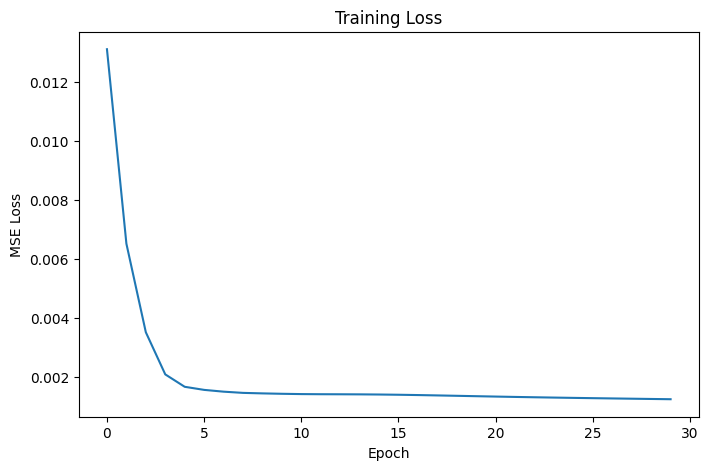

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

## Model Evaluation

The model is evaluated using MSE, RMSE, and MAE on the test data.

In [16]:
def evaluate_model(model):
    model.eval()

    preds = []
    actual = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            pred = model(xb)

            preds.append(pred.cpu().numpy())
            actual.append(yb.numpy())

    preds = np.vstack(preds)
    actual = np.vstack(actual)

    preds = preds.reshape(-1, PRED_HORIZON, len(features))
    actual = actual.reshape(-1, PRED_HORIZON, len(features))

    pred_inv = []
    actual_inv = []

    for i in range(len(preds)):
        pred_inv.append(scaler.inverse_transform(preds[i]))
        actual_inv.append(scaler.inverse_transform(actual[i]))

    pred_inv = np.array(pred_inv)
    actual_inv = np.array(actual_inv)

    y_true = actual_inv.reshape(-1)
    y_pred = pred_inv.reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print("Performance on all 11 features")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)

    return pred_inv, actual_inv

In [17]:
preds, actual = evaluate_model(model)

Performance on all 11 features
MSE : 2.996417681540326e+27
RMSE: 54739544038476.664
MAE : 9437872914432.0


## Date-Wise Actual vs Predicted Plot

This graph compares actual and predicted Close price on the test dates.

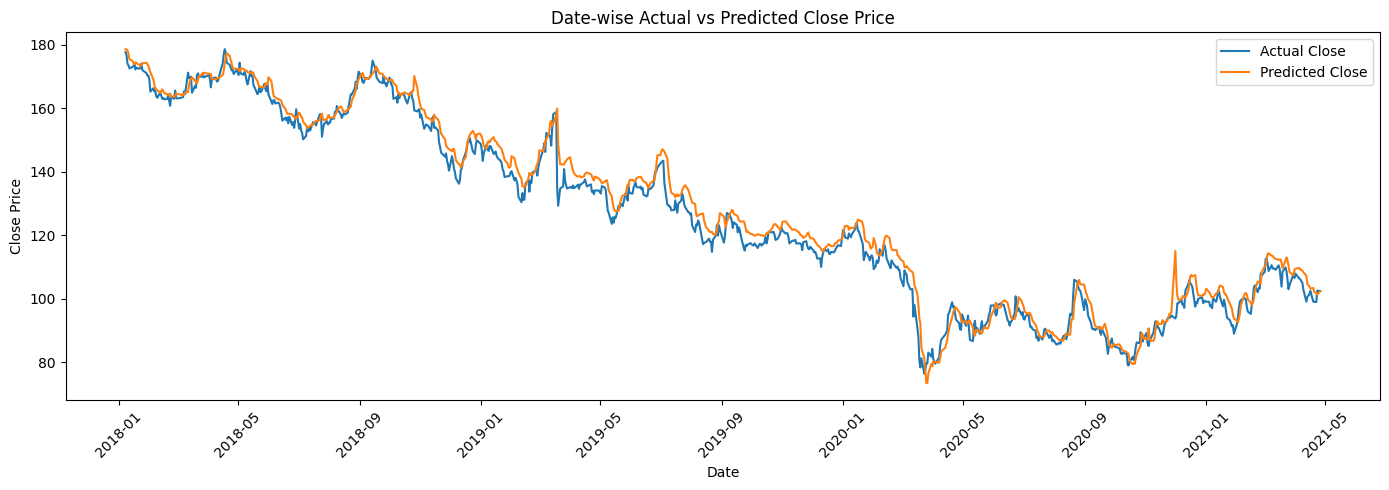

In [18]:
close_index = features.index("Close")

pred_close = preds[:, 0, close_index]
true_close = actual[:, 0, close_index]
plot_dates = test_dates.iloc[:len(true_close)]

plt.figure(figsize=(14, 5))
plt.plot(plot_dates, true_close, label="Actual Close")
plt.plot(plot_dates, pred_close, label="Predicted Close")
plt.title("Date-wise Actual vs Predicted Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

The notebook follows the required machine learning pipeline: data cleaning, train-test split, normalization, sequence chunking, PyTorch model training, evaluation, and date-wise plotting.